In [25]:
import h5py
import math
import numpy as np
import matplotlib.pyplot as plt

In [2]:
GAMBIT_RANDOM = "FS_MSSM7atQ_random_gambit.hdf5"
GAMBIT_DIVER = "FS_MSSM7atQ_diver_relicd_gambit.hdf5"
MODELGEN = "SP_MSSM7atQ_random_modelgen.hdf5"
VERSION = "v5"

In [3]:
def open_scan(file_name: str, version: str = VERSION) -> h5py.File:
    """open a scan file and return the h5py File object"""
    if "modelgen" in file_name.lower():
        file_path = f"../data/modelgen-output/modelgen-{version}/{file_name}"
    elif "gambit" in file_name.lower():
        file_path = f"../data/gambit-output/gambit-{version}/{file_name}"
    else:
        raise ValueError("File name must contain 'modelgen' or 'gambit'\nNAMING CONVENTION: <framework>-<version>/<filename>")

    return h5py.File(file_path, "r")["MSSM"]

In [13]:
scan_modelgen = open_scan(MODELGEN)
scan_gambit_random = open_scan(GAMBIT_RANDOM)
scan_gambit_diver = open_scan(GAMBIT_DIVER)

mask = scan_gambit_diver["#RD_oh2 @DarkBit::RD_oh2_MicrOmegas_isvalid"][:] == 1
lnL_oh2_gd = scan_gambit_diver["#lnL_oh2 @DarkBit::lnL_oh2_upperlimit"][mask]
oh2_gd = scan_gambit_diver["#RD_oh2 @DarkBit::RD_oh2_MicrOmegas"][mask]

mask = (scan_modelgen["MO_Omega"][:] != -1) & (scan_modelgen["MO_Omega"][:] < 1)
oh2_mg = scan_modelgen["MO_Omega"][mask]



## Likelihood Calculation

In [18]:
oh2_theory = np.linspace(0, 1, 1000)
oh2_theoryerr = 0.05
oh2_obs = 0.11933
oh2_obserr = 0.00091

In [43]:
def gaussian_upper_limit_loglike(theory, obs, theoryerr, obserr, profile_systematics: bool = False) -> float:
    """Calculate the log-likelihood for a Gaussian upper limit."""
    theoryerr *= theory
    errsq = theoryerr**2 + obserr**2
    if profile_systematics:
        prefactor = -0.5 * np.log(2*np.pi*errsq)
        loglike = prefactor - 0.5*np.power((theory - obs), 2)/errsq if theory > obs else prefactor
        return loglike
    else:
        prefactor = -0.5 * np.log(8*np.pi)
        diff = obs - theory
        like = np.exp(-0.5*diff**2/errsq)/np.sqrt(errsq)
        like *= math.erfc(obserr * diff / (theoryerr * np.sqrt(2*errsq)))
        like += math.erfc(-diff / (np.sqrt(2)*theoryerr))/obserr
        loglike = prefactor + 1.17549e-38 if like==0 else prefactor + np.log(like)
        return loglike

lnL_oh2_theory = [gaussian_upper_limit_loglike(oh2_theory[i], oh2_obs, oh2_theoryerr, oh2_obserr, profile_systematics=False) for i in range(len(oh2_theory))]
lnL_oh2_mg = [gaussian_upper_limit_loglike(oh2_mg[i], oh2_obs, oh2_theoryerr, oh2_obserr) for i in range(len(oh2_mg))]

/tmp/ipykernel_2291/1081192430.py:13: RuntimeWarning: divide by zero encountered in scalar divide
  like *= math.erfc(obserr * diff / (theoryerr * np.sqrt(2*errsq)))
/tmp/ipykernel_2291/1081192430.py:14: RuntimeWarning: divide by zero encountered in scalar divide
  like += math.erfc(-diff / (np.sqrt(2)*theoryerr))/obserr


In [39]:
print("SCAN             | VALID/ATTEMPTED")
print("-----------------------------------")
print(f"GAMBIT diver     | {len(oh2_gd)}/{len(scan_gambit_diver["#RD_oh2 @DarkBit::RD_oh2_MicrOmegas_isvalid"][:])}\t{(len(oh2_gd)/len(scan_gambit_diver["#RD_oh2 @DarkBit::RD_oh2_MicrOmegas_isvalid"][:]))*100:.2f}%")
print(f"MODELGEN         | {len(oh2_mg)}/{len(scan_modelgen["MO_Omega"][:])}\t{(len(oh2_mg)/len(scan_modelgen["MO_Omega"][:]))*100:.2f}%")

SCAN             | VALID/ATTEMPTED
-----------------------------------
GAMBIT diver     | 27/22000	0.12%
MODELGEN         | 103/50000	0.21%


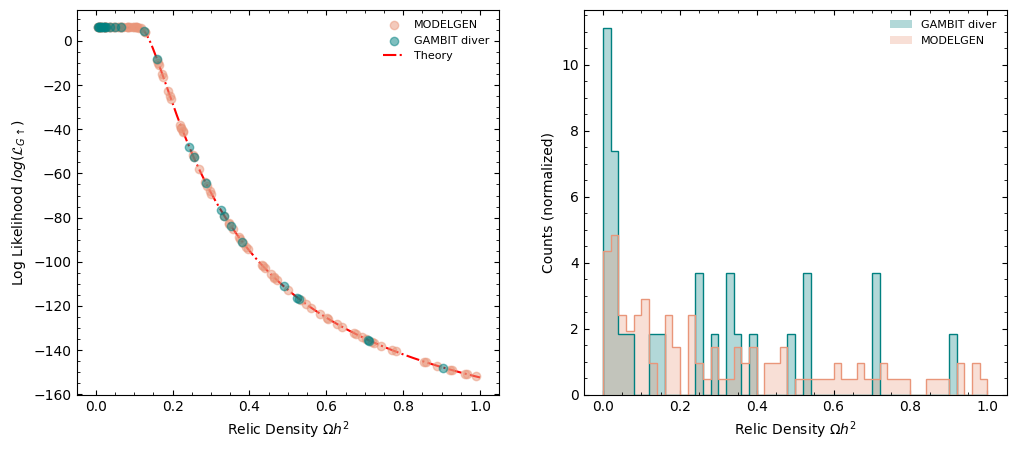

In [45]:
fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.scatter(oh2_mg, lnL_oh2_mg, alpha=0.5, color='darksalmon', label="MODELGEN")
ax1.scatter(oh2_gd, lnL_oh2_gd, alpha=0.5, color='teal', label="GAMBIT diver")
ax1.plot(oh2_theory, lnL_oh2_theory, color='red', linestyle='-.',zorder=0, label="Theory")
ax1.minorticks_on()
ax1.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax1.legend(frameon=False, fontsize=8)
ax1.set_xlabel("Relic Density $\\Omega h^2$")
ax1.set_ylabel("Log Likelihood $log(\\mathcal{L}_{G \\uparrow})$")

ax2.hist(oh2_gd, bins=50, range=(0,1), density=True, alpha=0.3, histtype='stepfilled', color='teal', label="GAMBIT diver")
ax2.hist(oh2_mg, bins=50, range=(0,1), density=True, alpha=0.3, histtype='stepfilled', color='darksalmon', label="MODELGEN")
ax2.hist(oh2_gd, bins=50, range=(0,1), density=True, histtype='step', color='teal')
ax2.hist(oh2_mg, bins=50, range=(0,1), density=True, histtype='step', color='darksalmon')
ax2.minorticks_on()
ax2.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax2.set_xlabel("Relic Density $\\Omega h^2$")
ax2.set_ylabel("Counts (normalized)")
ax2.legend(frameon=False, fontsize=8)

plt.show()